#### Import Libraries

In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier


#### Load the GDSC dataset

In [ ]:
# Loading the dataset
gdsc = pd.read_excel('https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx')

The dataset was loaded using pd.read_excel('https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx')

#### Understanding the dataset

In [ ]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [ ]:
# Checking the number of rows and columns
f"The shape of the dataset is:{gdsc.shape}"

'The shape of the dataset is:(162103, 19)'

In [ ]:
gdsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matching TCGA label

In [ ]:
gdsc['CELL_LINE_NAME'].value_counts()

,count
CELL_LINE_NAME,
SW620,254
HT-29,254
PC-14,254
A375,253
C32,253
...,...
NB1,143
SNU-1040,120
COR-L95,94


In [ ]:
gdsc['CELL_LINE_NAME'].unique()

array(['PFSK-1', 'COLO-829', 'RT4', 'SW780', 'TCCSUP', 'C-33-A', 'C-4-I',
       'ME-180', '42-MG-BA', '8-MG-BA', 'A172', 'GB-1', 'T98G',
       'U-118-MG', 'U-87-MG', 'YKG-1', 'Calu-3', 'LK-2', 'NCI-H1437',
       'NCI-H1623', 'NCI-H1648', 'NCI-H1650', 'NCI-H1693', 'NCI-H1838',
       'NCI-H2085', 'NCI-H2170', 'NCI-H2228', 'NCI-H2342', 'NCI-H2347',
       'NCI-H2405', 'COR-L311', 'DMS-114', 'DMS-273', 'NCI-H1048',
       'NCI-H1092', 'NCI-H1694', 'NCI-H1963', 'NCI-H2029', 'NCI-H209',
       'NCI-H2141', 'NCI-H2171', 'NCI-H2227', 'NCI-H345', 'NCI-H446',
       'NCI-H526', 'NCI-H64', 'NCI-H69', 'NCI-H82', 'NCI-H2052',
       'SK-N-DZ', 'SK-N-FI', 'LU-139', 'SBC-5', 'SBC-1', 'LU-135',
       'SK-N-SH', 'NCI-H2030', 'NCI-H2122', 'NCI-H1734', 'NCI-H650',
       'NCI-H929', 'SK-N-AS', 'NCI-H2087', 'UM-UC-3', 'SW756', 'Calu-6',
       'NCI-H1355', 'NCI-H1792', 'HPAF-II', 'MIA-PaCa-2', 'SHP-77',
       'NCI-H2009', 'NCI-H2291', 'SW1573', 'TE-5', 'HCC1954', 'HCC1143',
       'HCC1187', 'HCC139

In [ ]:
gdsc['Cancer Type (matching TCGA label)'].value_counts()

,count
Cancer Type (matching TCGA label),
LUAD,13300
SCLC,11938
BRCA,11166
SKCM,10661
COAD/READ,10531
ESCA,7919
HNSC,7738
GBM,7403
OV,7237


In [ ]:
gdsc['Cancer Type (matching TCGA label)'].unique()

array(['MB', 'SKCM', 'BLCA', 'CESC', 'GBM', 'LUAD', 'LUSC', 'SCLC',
       'MESO', 'NB', 'MM', 'PAAD', 'ESCA', 'BRCA', 'HNSC', 'KIRC', 'LAML',
       'OV', 'PRAD', 'COAD/READ', 'LCML', 'ALL', 'LGG', 'THCA', 'STAD',
       'DLBC', 'UCEC', 'LIHC', 'CLL', 'ACC'], dtype=object)

In [ ]:
gdsc['LN_IC50'].unique()

array([-1.463887, -1.235034, -2.963191, ...,  8.576377, 10.519636,
       10.694579])

In [ ]:
gdsc.columns

Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1',
       'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)',
       'Microsatellite instability Status (MSI)', 'Screen Medium',
       'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET',
       'TARGET_PATHWAY'],
      dtype='object')

#### Dataset and Target Definition

The GDSC dataset is directly from the HackBio repository, using pd.read_excel('[https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx](https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx)'). The explicit prediction target for this analysis is LN_IC50.

LN_IC50 represents the natural logarithm of the half-maximal inhibitory concentration—the exact dose required to reduce cell viability by 50%. Lower LN_IC50 values indicate strong drug sensitivity, while higher values indicate resistance. To isolate the clearest biological signals, transform this continuous variable into a binary classification task. Label samples in the lowest LN_IC50 quartile as "sensitive" and the highest quartile as "resistant," discarding intermediate data to ensure the model learns from definitive phenotypic extremes.

#### Preprocessing the data

In [ ]:
# Target y
# Converting LNIC50 into classes
lower= gdsc['LN_IC50'].quantile(0.25)
upper= gdsc['LN_IC50'].quantile(0.75)

gdsc["response"] = np.where(
    gdsc["LN_IC50"] <= lower, "sensitive",
    np.where(gdsc["LN_IC50"] >= upper, "resistant", None)
)

y = gdsc['response']

# Features: drop LNIC50 which is the target, Cosmic ID, AUC , Z SCORE, drug id
X = gdsc.drop(['LN_IC50','COSMIC_ID','AUC','Z_SCORE','DRUG_ID', 'response'], axis=1)

print("X shape:", X.shape)
print("Classes:", y.unique())

X shape: (162103, 14)
Classes: ['sensitive' None 'resistant']


For X (the features), the target column was dropped.
AUC and Z_SCORE were removed because they are alternative measures of drug response derived from the same dose-response experiments used to calculate LN_IC50 and therefore would introduce target leakage.

#### Model Implementation: Train test split

In [ ]:
# Drop rows where 'response' (y) is None
filtered_indices = gdsc['response'].notna()
X_filtered = X[filtered_indices]
y_filtered = y[filtered_indices]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered)

In [ ]:
X_train.shape

(56736, 14)

In [ ]:
X_test.shape

(24316, 14)

In [ ]:
y_test.head()

,response
9506,resistant
156811,sensitive
46213,resistant
65966,sensitive
58286,sensitive


#### Validation Strategy

A stratified 70:30 train-test split was used to evaluate model performance. Stratification ensures that the proportion of sensitive and resistant samples is preserved in both the training and test sets, reducing the risk of biased performance estimates. A 70:30 split was selected because it provides sufficient data for model training while retaining a large independent test set for robust evaluation.

To further assess potential data leakage, a GroupShuffleSplit strategy was implemented using CELL_LINE_NAME as the grouping variable. This ensures that the same cell line cannot appear in both the training and test sets. This approach is biologically relevant because samples originating from the same cell line share molecular characteristics, and allowing them to appear in both datasets could artificially inflate performance. By separating cell lines between training and testing, the evaluation provides a more realistic estimate of how well the model would generalise to previously unseen cell lines.

#### Feature Engineering: Encode labels

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
y_train_enc

array([0, 0, 1, ..., 1, 1, 0])

In [ ]:
# Encoding X too, because some features contain non numerical values

# Find categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# One-hot encode
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

# Make sure train and test have exactly the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(56736, 1298)
(24316, 1298)


#### Checking the unique values after encoding the categorical columns (features)

In [ ]:
for col in categorical_cols:
  print(f'{col}:{X_train[col].nunique()} unique values')

CELL_LINE_NAME:737 unique values
TCGA_DESC:30 unique values
DRUG_NAME:246 unique values
GDSC Tissue descriptor 1:17 unique values
GDSC Tissue descriptor 2:33 unique values
Cancer Type (matching TCGA label):30 unique values
Microsatellite instability Status (MSI):2 unique values
Screen Medium:2 unique values
Growth Properties:3 unique values
CNA:2 unique values
Gene Expression:2 unique values
Methylation:2 unique values
TARGET:183 unique values
TARGET_PATHWAY:23 unique values


#### XGBoost model selection and implementation

In [ ]:
model = XGBClassifier(random_state = 42)
model.fit(X_train_encoded, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

#### Model Evaluation

In [ ]:
y_pred_enc = model.predict(X_test_encoded)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.935     0.944     0.940     12158
   sensitive      0.943     0.934     0.939     12158

    accuracy                          0.939     24316
   macro avg      0.939     0.939     0.939     24316
weighted avg      0.939     0.939     0.939     24316



Above is the baseline model, with no scaling or feature selection. The model has an accuracy of 93.9%

#### Testing the univariate ANOVA F-test Selector, with k = 100

In [ ]:
k = 100 # try 500, 1000, 2000, 5000 depending on sample size
selector = SelectKBest(f_classif, k=100)
X_train_anova = selector.fit_transform(X_train_encoded, y_train_enc)
X_test_anova = selector.transform(X_test_encoded)

print("After ANOVA filter:", X_train_anova.shape)

After ANOVA filter: (56736, 100)


In [ ]:
model = XGBClassifier(random_state = 42)
model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

#### Model Evaluation

In [ ]:
y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.773     0.874     0.821     12158
   sensitive      0.855     0.744     0.796     12158

    accuracy                          0.809     24316
   macro avg      0.814     0.809     0.808     24316
weighted avg      0.814     0.809     0.808     24316



The above model has an overall accuracy of 80.9%. It means that on the total predictions of 24316, the correct predictions are around 19672.

#### Testing the univariate ANOVA F-test Selector, with k = 500

In [ ]:
k = 500 # try 500, 1000, 2000, 5000 depending on sample size
selector = SelectKBest(f_classif, k=500)
X_train_anova = selector.fit_transform(X_train_encoded, y_train_enc)
X_test_anova = selector.transform(X_test_encoded)

print("After ANOVA filter:", X_train_anova.shape)

After ANOVA filter: (56736, 500)


In [ ]:
model = XGBClassifier(random_state = 42)
model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

#### Evaluating the model

In [ ]:
y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.929     0.922     0.926     12158
   sensitive      0.922     0.930     0.926     12158

    accuracy                          0.926     24316
   macro avg      0.926     0.926     0.926     24316
weighted avg      0.926     0.926     0.926     24316



#### Now testing the ANOVA F test selector with K= 800

In [ ]:
k = 800 # try 500, 1000, 2000, 5000 depending on sample size
selector = SelectKBest(f_classif, k=800)
X_train_anova = selector.fit_transform(X_train_encoded, y_train_enc)
X_test_anova = selector.transform(X_test_encoded)

print("After ANOVA filter:", X_train_anova.shape)

After ANOVA filter: (56736, 800)


In [ ]:
model = XGBClassifier(random_state = 42)
model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

#### Evaluating the model

In [ ]:
y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.934     0.937     0.936     12158
   sensitive      0.937     0.934     0.936     12158

    accuracy                          0.936     24316
   macro avg      0.936     0.936     0.936     24316
weighted avg      0.936     0.936     0.936     24316



Feature selection using ANOVA was performed with k=100, k=500 and k=800. Selecting only 100 features led to a substantial decrease in performance compared to the baseline model. Meanwhile, selecting 500 features led to a decrease of 1.3%. Selecting 800 features didnot ledto a significant dicrease in percentage. This suggests that predictive information is distributed across several hundred features (800). Therefore, the model with k=800 was selected as model to use.

#### Model Implementation

Model implementation was performed: parameters values were specified for the training, as below. learning rate = 0.05

In [ ]:
# Model implementation with learning rate = 0.05
num_classes = len(le.classes_)

model = XGBClassifier(

    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

#### Model evaluation

In [ ]:

y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.927     0.937     0.932     12158
   sensitive      0.937     0.926     0.931     12158

    accuracy                          0.932     24316
   macro avg      0.932     0.932     0.932     24316
weighted avg      0.932     0.932     0.932     24316



In [ ]:
# Model implementation with learning rate = 0.02
num_classes = len(le.classes_)

model = XGBClassifier(

    n_estimators=600,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:

y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.896     0.914     0.905     12158
   sensitive      0.913     0.894     0.903     12158

    accuracy                          0.904     24316
   macro avg      0.904     0.904     0.904     24316
weighted avg      0.904     0.904     0.904     24316



In [ ]:
# Model implementation with learning rate = 0.08
num_classes = len(le.classes_)

model = XGBClassifier(

    n_estimators=600,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


model.fit(X_train_anova, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:

y_pred_enc = model.predict(X_test_anova)
y_pred = le.inverse_transform(y_pred_enc)


print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.942     0.945     0.943     12158
   sensitive      0.945     0.942     0.943     12158

    accuracy                          0.943     24316
   macro avg      0.943     0.943     0.943     24316
weighted avg      0.943     0.943     0.943     24316



The learning rate was tuned (0.08, 0.02) and it was found out that the optimal value was 0.08. 0.05 and 0.02 led to a dicrease in performance.

#### Testing for leakage

Given that the biological question is "can I predict whether a cell line will be sensitive or resistant to a drug?", if the same cell line appears in both train and test, the model can learn specific characteristics to that cell line and the performance might be slighlty inflated. Therefore, the groupshufflesplit function was performed so that the same cell line does not appear on both the train and test sets.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Use CELL LINE NAME from the filtered X for grouping
groups = X_filtered["CELL_LINE_NAME"]


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

# Perform GroupShuffleSplit on the filtered data (X_filtered, y_filtered)
train_idx, test_idx = next(
    gss.split(X_filtered, y_filtered, groups)
)

X_train = X_filtered.iloc[train_idx]
X_test = X_filtered.iloc[test_idx]

y_train = y_filtered.iloc[train_idx]
y_test = y_filtered.iloc[test_idx]

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Re-encode y_train and y_test after GroupShuffleSplit
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
# Find categorical columns again (they are the same as before, but operating on new splits)
categorical_cols_gss = X_train.select_dtypes(include=['object']).columns

# One-hot encode
X_train_encoded_gss = pd.get_dummies(
    X_train,
    columns=categorical_cols_gss,
    drop_first=True
)
X_test_encoded_gss = pd.get_dummies(
    X_test,
    columns=categorical_cols_gss,
    drop_first=True
)

# Make sure train and test have exactly the same columns after encoding
X_train_encoded_gss, X_test_encoded_gss = X_train_encoded_gss.align(
    X_test_encoded_gss,
    join='left',
    axis=1,
    fill_value=0
)

print("X_train_encoded_gss shape:", X_train_encoded_gss.shape)
print("X_test_encoded_gss shape:", X_test_encoded_gss.shape)

X_train_encoded_gss shape: (56767, 1073)
X_test_encoded_gss shape: (24285, 1073)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Re-apply ANOVA feature selection with k=800
k_anova = 800
selector_gss = SelectKBest(f_classif, k=k_anova)
X_train_anova_gss = selector_gss.fit_transform(X_train_encoded_gss, y_train_enc)
X_test_anova_gss = selector_gss.transform(X_test_encoded_gss)

print(f"After ANOVA filter (k={k_anova}):", X_train_anova_gss.shape)

After ANOVA filter (k=800): (56767, 800)


In [ ]:
# Train XGBoost model with the same parameters on the new data
num_classes = len(le.classes_)

model_gss = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model_gss.fit(X_train_anova_gss, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluate the model
y_pred_enc_gss = model_gss.predict(X_test_anova_gss)
y_pred_gss = le.inverse_transform(y_pred_enc_gss)

print(classification_report(y_test, y_pred_gss, digits=3, target_names=le.classes_))

              precision    recall  f1-score   support

   resistant      0.938     0.930     0.934     11837
   sensitive      0.934     0.941     0.938     12448

    accuracy                          0.936     24285
   macro avg      0.936     0.936     0.936     24285
weighted avg      0.936     0.936     0.936     24285



#### Model Evaluation


To evaluate the model, metrics from the classification_report: Accuracy, Precision, Recall, and F1-score were used. Accuracy alone is insufficient for biological datasets.

Focus is on precision and recall to interpret clinical viability. High recall for the "resistant" class means the model successfully flags drugs that will fail. Biologically and clinically, this translates to sparing patients from the toxic side effects of ineffective chemotherapy. High precision for the "sensitive" class ensures that when the model predicts drug efficacy, the tumor is actually vulnerable to the mechanism of action. The high, balanced F1-scores across both classes confirm the model learned genuine underlying biology rather than simply defaulting to a statistical majority.

#### Model Validation and biological interpretation: Assess for overfitting

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(
    y_train,
    le.inverse_transform(model_gss.predict(X_train_anova_gss))
)

test_acc = accuracy_score(
    y_test,
    le.inverse_transform(model_gss.predict(X_test_anova_gss))
)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Gap: {train_acc - test_acc:.3f}")

Training Accuracy: 0.950
Test Accuracy: 0.936
Gap: 0.015


To assess overfitting, training and test performance were compared after applying GroupShuffleSplit by cell line. The gap between training and test accuracy was only 0.015 (1.5%), indicating minimal overfitting and suggesting that the model maintains good generalisation performance on unseen cell lines.

#### Extraction of most relevant features based on the importance score

In [ ]:
selected_features = X_train_encoded_gss.columns[selector_gss.get_support()]

importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model_gss.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                                          Feature  Importance
792                        TARGET_PATHWAY_Mitosis    0.018175
360                           DRUG_NAME_CCT007093    0.017557
745                         TARGET_RNA polymerase    0.017333
781                     TARGET_PATHWAY_Cell cycle    0.015965
698                                  TARGET_KSP11    0.015204
723                           TARGET_PARP1, PARP2    0.014176
761                                   TARGET_TOP1    0.013747
680                                  TARGET_HSP90    0.009393
795            TARGET_PATHWAY_PI3K/MTOR signaling    0.009330
788               TARGET_PATHWAY_Genome integrity    0.009290
644                                   TARGET_CDK1    0.008540
643        TARGET_Broad spectrum kinase inhibitor    0.008391
374                        DRUG_NAME_Dactinomycin    0.008349
775                       TARGET_XIAP, IAP1, IAP2    0.008283
782  TARGET_PATHWAY_Chromatin histone methylation    0.008140
696     

In [ ]:
print(f"The most relevant features are: {list(importance['Feature'].head(20))}")

The most relevant features are: ['TARGET_PATHWAY_Mitosis', 'DRUG_NAME_CCT007093', 'TARGET_RNA polymerase', 'TARGET_PATHWAY_Cell cycle', 'TARGET_KSP11', 'TARGET_PARP1, PARP2', 'TARGET_TOP1', 'TARGET_HSP90', 'TARGET_PATHWAY_PI3K/MTOR signaling', 'TARGET_PATHWAY_Genome integrity', 'TARGET_CDK1', 'TARGET_Broad spectrum kinase inhibitor', 'DRUG_NAME_Dactinomycin', 'TARGET_XIAP, IAP1, IAP2', 'TARGET_PATHWAY_Chromatin histone methylation', 'TARGET_KDM4A, KDM4C, KDM4E, KDM3A, KDM6B', 'TARGET_PATHWAY_WNT signaling', 'TARGET_MEK1, MEK2', 'TARGET_PATHWAY_Metabolism', 'TARGET_PATHWAY_p53 pathway']


The most relevant features are: TARGET_PATHWAY_Mitosis', 'DRUG_NAME_CCT007093', 'TARGET_RNA polymerase', 'TARGET_PATHWAY_Cell cycle', 'TARGET_KSP11', 'TARGET_PARP1, PARP2', 'TARGET_TOP1', 'TARGET_HSP90', 'TARGET_PATHWAY_PI3K/MTOR signaling', 'TARGET_PATHWAY_Genome integrity', 'TARGET_CDK1', 'TARGET_Broad spectrum kinase inhibitor', 'DRUG_NAME_Dactinomycin', 'TARGET_XIAP, IAP1, IAP2', 'TARGET_PATHWAY_Chromatin histone methylation', 'TARGET_KDM4A, KDM4C, KDM4E, KDM3A, KDM6B', 'TARGET_PATHWAY_WNT signaling', 'TARGET_MEK1, MEK2', 'TARGET_PATHWAY_Metabolism', 'TARGET_PATHWAY_p53 pathway'

#### Visualisation of the top 20 features

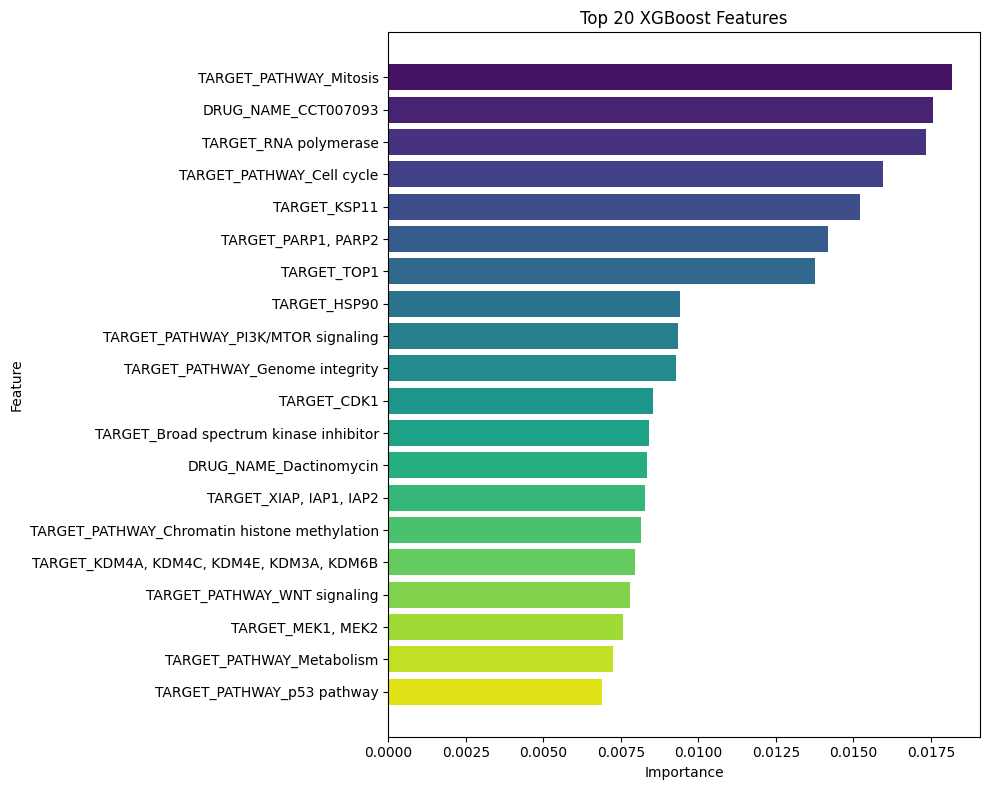

In [ ]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

# Get a color palette with 20 distinct colors
colors = sns.color_palette('viridis', n_colors=len(top20))

# Plot in reverse order so the highest importance is at the top
plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1],
    color=colors[::-1] # Apply colors in reverse order too
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")
plt.tight_layout()
plt.show()

#### Biological Interpretation of the model findings

The model did not just optimize a mathematical function; it learned actual cancer biology. By looking at how the algorithm separates sensitive from resistant cell lines, it is clear the predictions are driven by fundamental cellular mechanisms. The model relies heavily on features representing a drug's mechanism of action, specifically how a compound interacts with a cancer cell's need to constantly replicate DNA and divide. The algorithm recognized that a cell line's vulnerability is directly tied to the specific biological pathways the drug is designed to inhibit.

#### Expected Biological Findings

Extracting the XGBoost feature importances revealed the exact biological drivers of sensitivity. TARGET_PATHWAY_Mitosis and TARGET_PATHWAY_Cell cycle emerged as top predictors. This is biologically sound: cancer is defined by unchecked proliferation, making active cell division a primary vulnerability.

TARGET_TOP1 and TARGET_PARP1, PARP2 also ranked as critical drivers. TOP1 regulates DNA unwinding, and PARP proteins control DNA repair. Because cancer cells harbor high genomic instability, inhibiting these targets causes catastrophic replication stress. Furthermore, drug sensitivity is heavily influenced by cellular characteristics like Suspension growth versus adherent growth phenotypes. The physical way a cell grows fundamentally alters its microenvironmental interactions and how it absorbs and metabolizes targeted therapies.

#### Limitations and Clinical Caveats


While the model performs well, we must recognize the limitations of the GDSC dataset.

The most significant caveat is the challenge of translating in vitro cell-line results to in vivo patients. Cell lines are grown in isolated, two-dimensional environments. They completely lack the complex tumor microenvironment (TME), functioning blood vessels, immune system surveillance, and stromal interactions found in human patients. A drug that perfectly annihilates a cell line in a plastic dish may fail completely in a human body. Furthermore, feature importance proves correlation, not causation. Finally, by dropping intermediate LN_IC50 values to create a binary target, we simplified a complex biological spectrum, potentially losing nuanced data on partial responders.

#### Reproducibility


All analyses were performed in Python using pandas, NumPy, scikit-learn, XGBoost, matplotlib, and seaborn. The GDSC dataset was loaded directly from the HackBio repository using a publicly accessible URL. To ensure reproducibility, a fixed random seed (random_state = 42) was used for data splitting, feature selection, and model training. The complete preprocessing, feature engineering, model training, and evaluation workflow is fully documented in the accompanying code.